# Smoothing

Often we might want to interpret our association strength between features as probabilities (e.g. "likelihood of being connected"). 
This brings problems with it, if unobserved combinations are recieving probability 0., even when they should still be considered _possible_ with sufficient sampling.[^1]


[^1]: As another consideration, many of the association measures can be used as kernels or distance (pseudo-)metrics. Having 0 or undefined similarity between points makes distance calculations or similarity scoring ... fraught. 

As the thinking goes, just because you've never seen something, doesn't make it _impossible_, just improbable. 
How improbable depends on your priors. `affinis` comes with support for basic additive smoothing under a beta prior. 


In [24]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path

import affinis.associations as aff
from affinis.plots import hinton

plt.rc('figure', figsize=(4.0, 3.0))
imgpath=Path('../../docs/user-guide/img/')

n_cols=15
n_rows=30
B = nx.bipartite.random_graph(n_cols,n_rows, .25, seed=2)
n = list(B.nodes)[n_cols:]

X = nx.bipartite.biadjacency_matrix(B, n).toarray()

## Basic Additive Smoothing

The simplest way to "smooth" your results is to add at least one observation of each possible kind to your dataset: two trials i.e. one success and one failure. 
Add them to your overall counts to get a smoothed probability (Laplace smoothing)

$$
P = \frac{\textrm{successes}+1}{\textrm{trials}+2}
$$

Of course, you might not want to  these "pseudocounts" to be worth as much as the "real" ones. 
Adding pseudocounts of 1/2 is called using a Jeffrey's Prior. 

Let's compare. 
`affinis` makes applying pseudocounts to nearly all of the association measures _trivial_. 

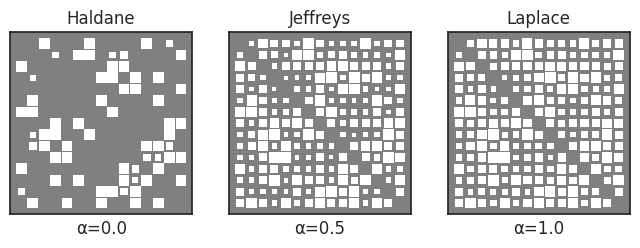

In [38]:
f,axs = plt.subplots(nrows=1, ncols=3, figsize=(8,4))
settings = {'Haldane':0., 'Jeffreys':0.5, 'Laplace':1.}

for n, (lab, a) in enumerate(settings.items()): 
    ax = axs.flatten()[n]
    fp = aff.forest_pursuit(X, pseudocts=a)
    hinton(fp, ax=ax)
    ax.set_title(lab)
    ax.set_xlabel(f'α={a:.1f}')
    
plt.savefig(imgpath/'add-smooth.webp')

![additive priors](img/add-smooth.webp)

## Beta Priors 

It turns out that these are all special cases of a beta-binomial distribution, with a symmetric prior. 

Of course, there's no reason to necessarily stick to a symetric prior. 
`affinis` allows for tuples `(a,b)` as pseudocount parameters, so that you can deal with smoothing differently at the low and high ends of your association scales. 

With parameters `(a,b)`, the posterior expected value of the association measure will be 

$$
P = \frac{\textrm{successes}+a}{\textrm{trials}+a+b}
$$

Of course, this assumes that we can represent a given measure as a probability in the form (successes/trials). 
While most can, a few (like [hyperbolic projection][affinis.associations.hyperbolic_project]) do not have a form that is easily representable as a ratio. 


### "Zero sum" Prior

We provide a convenience to enforce `a+b=1`, which ensures the prior expected value is `a`, and when used for sampling purposes can prefer values of 0 or 1 (i.e. a bathtub prior). 
This is done with `zero-sum`, like so: 

`pseudocts=('zero-sum',0.1)`

See [docs][affinis.priors] for more. 

### Animation

It's useful to get a sense for how your association values change, as your parameters do. 
[`hinton`][affinis.plots.hinton] provides a convenience parameter to assist with animation, by updating existing `PathCollection` properties, directly. 

In [39]:
psdcts = np.linspace(0,1)
psdcts = np.hstack((
    np.zeros_like(psdcts),
    psdcts,
    np.ones_like(psdcts),
    psdcts[::-1]
))

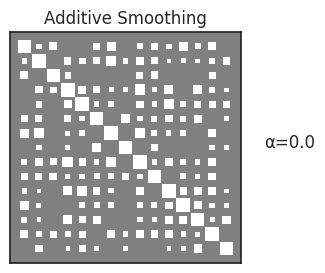

In [40]:
coo = aff.ochiai(X, pseudocts=1.)

fig, ax = plt.subplots()
scat = hinton(coo, ax=ax)
plt.title('Additive Smoothing')
annot = ax.annotate('α=0.0',(1.1,0.5), xycoords='axes fraction')

def update(frame):
    psdct = psdcts[frame]
    coo = aff.ochiai(X, pseudocts=psdct)
    newscat = hinton(coo, update_from=scat)
    annot.set_text(f'α={psdct:.1f}')
    return (newscat ,annot)

ani = animation.FuncAnimation(fig=fig, func=update, frames=psdcts.shape[0], interval=30)
ani.save(filename=imgpath/"smoothing.webp", writer="pillow")

![](img/smoothing.webp)

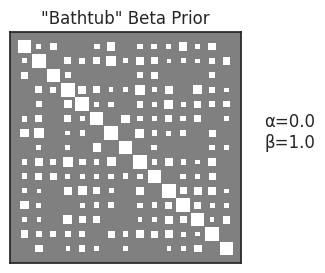

In [41]:
coo = aff.ochiai(X, pseudocts=('zero-sum',1.))

fig, ax = plt.subplots()
scat = hinton(coo, ax=ax)
plt.title('"Bathtub" Beta Prior')
annot = ax.annotate('α=0.0\nβ=1.0',(1.1,0.5), xycoords='axes fraction')

def update(frame):
    psdct = ('zero-sum',psdcts[frame])
    coo = aff.ochiai(X, pseudocts=psdct)
    newscat = hinton(coo, update_from=scat)
    annot.set_text(f'α={psdct[1]:.1f}\nβ={1-psdct[1]:.1f}')
    return (newscat ,annot)

ani = animation.FuncAnimation(fig=fig, func=update, frames=psdcts.shape[0], interval=30)
ani.save(filename=imgpath/"smoothing-zero-sum.webp", writer="pillow")

![](img/smoothing-zero-sum.webp)